In [6]:
%run Packages_and_Functions.ipynb


In [24]:
def experiment_change_in_optimal_size(n1=30,n2=100,p = lambda x: np.power(x,-0.5),AVG = 30):
    """
    p would be a function of n, or a constant function. But we definitly expect it to be a function N -> (0,1)
    """
    N = range(n1,n2)
    ## Set up lists to collect results
    # LHS_HUR = np.zeros(len(N))
    # LHS_HUR_ERR = np.zeros(len(N))
    # LHS_HUR_EXP_FRAC = np.zeros(len(N))
    # LHS_HUR_EDGE_FRAC = np.zeros(len(N))
    PIVOT_HUR = np.zeros(len(N))
    PIVOT_HUR_ERR = np.zeros(len(N))
    PIVOT_HUR_EXP_FRAC = np.zeros(len(N))
    
    PIVOT_COMPLETE_HUR = np.zeros(len(N))
    PIVOT_COMPLETE_HUR_ERR = np.zeros(len(N))
    PIVOT_COMPLETE_HUR_EXP_FRAC = np.zeros(len(N))

    DOMR = np.zeros(len(N))
    DOMR_ERR = np.zeros(len(N))
    DOMR_EXP_FRAC = np.zeros(len(N))

    DOMR_COMPLETE = np.zeros(len(N))
    DOMR_COMPLETE_ERR = np.zeros(len(N))
    DOMR_COMPLETE_EXP_FRAC = np.zeros(len(N))
    # OPT = np.zeros(len(N))
    
    start_time = time.time()
    for i,n in enumerate(N):
        ### Keep track of progress
        if i % 5 == 0:
            print("Completed:" + str(i/len(N)*100) + "% \n" + "Elapsed Time: " + str((time.time() - start_time)/60))
            
        ## Keep the size of hitting sets over all iterations of the same graph size.
        # LHS_samples= list()
        PIVOT_samples=list()
        PIVOT_COMPLETE_samples=list()
        DOMR_samples=list()
        DOMR_COMPLETE_samples=list()
#         L1_samples= list()
        for j in range(AVG): # average over AVG instances
            B = False #Flag if current instance is connected
            while B == False:
                G = random_geometric_weighted_graph(n,p(n))
                ## Todo: Change this to iterate over all connected components
                B = G.is_connected()
                if B: #If the graph is connected
                    # S2 = left_edge_heuristic(G) 
                    S_DOMR = domr_alg(G)
                    if len(S_DOMR) > 0: # Make sure the graph is actually broken
                        # LHS_samples.append(len(S2)) #Save the HS size found in LHS
                        K = complete(G)
                        PIVOT_samples.append(len(pivot_heuristic(G))) #Save the HS size found in Pivot
                        DOMR_samples.append(len(S_DOMR)) # Save the optimal solution for DOMR, it's an upper bound on OPT

                        PIVOT_COMPLETE_samples.append(len(pivot_heuristic(K)))
                        DOMR_COMPLETE_samples.append(len(domr_alg(K)))
                        K = complete(G)
                        
                    else:
                        B = False # if it's not connected - resample (and again, make sure that it's connected)
                
#         L1_HUR[i] += sum((L1_samples))/AVG
#         L1_HUR_ERR = np.std(L1_samples)/np.sqrt(AVG) #error bars, is this the computation? Standard error

        ## After finishing AVG iterations, we can update the result
#         OPT[i] = sum(OPT_samples)/AVG 
        # LHS_HUR[i] = sum(LHS_samples)/AVG
        PIVOT_HUR[i] = sum(PIVOT_samples)/AVG
        DOMR[i] = sum(DOMR_samples)/AVG

        PIVOT_COMPLETE_HUR[i] = sum(PIVOT_COMPLETE_samples)/AVG
        DOMR_COMPLETE[i] = sum(DOMR_COMPLETE_samples)/AVG
        
        # Error Bars
        # LHS_HUR_ERR[i] = np.std(LHS_samples)/np.sqrt(AVG) 
        PIVOT_HUR_ERR[i] = np.std(PIVOT_samples)/np.sqrt(AVG) #error bars, is this the computation? Standard error
        DOMR_ERR[i] = np.std(DOMR_samples)/np.sqrt(AVG) 

        PIVOT_COMPLETE_HUR_ERR[i] = np.std(PIVOT_COMPLETE_samples)/np.sqrt(AVG) #error bars, is this the computation? Standard error
        DOMR_COMPLETE_ERR[i] = np.std(DOMR_COMPLETE_samples)/np.sqrt(AVG) 
        
        ## Compute ||SOL||_0 as a fraction over expected number of edges
        # LHS_HUR_EXP_FRAC[i] = LHS_HUR[i]/(n*(n-1)*p(n)/2)
        PIVOT_HUR_EXP_FRAC[i] = PIVOT_HUR[i]/(n*(n-1)*p(n)/2)
        DOMR_EXP_FRAC[i] = DOMR[i]/(n*(n-1)*p(n)/2)

        PIVOT_COMPLETE_HUR_EXP_FRAC[i] = PIVOT_COMPLETE_HUR[i]/(n*(n-1)*p(n)/2)
        DOMR_COMPLETE_EXP_FRAC[i] = DOMR_COMPLETE[i]/(n*(n-1)*p(n)/2)
        ## TODO: Compute ||SOL||_0 as a fraction over the empirical number of edges. Need deeper in the loops

    return PIVOT_HUR, DOMR, PIVOT_COMPLETE_HUR, DOMR_COMPLETE, PIVOT_HUR_ERR, DOMR_ERR, PIVOT_COMPLETE_HUR_ERR, DOMR_COMPLETE_ERR, PIVOT_HUR_EXP_FRAC, DOMR_EXP_FRAC, PIVOT_COMPLETE_HUR_EXP_FRAC, DOMR_COMPLETE_EXP_FRAC
#     return LHS_HUR,PIVOT_HUR,OPT



In [16]:
def experiment_change_in_optimal_size(n1=30,n2=100,p = lambda x: np.power(x,-0.5),AVG = 30):
    """
    p would be a function of n, or a constant function. But we definitly expect it to be a function N -> (0,1)
    """
    N = range(n1,n2)
    ## Set up lists to collect results
    # LHS_HUR = np.zeros(len(N))
    # LHS_HUR_ERR = np.zeros(len(N))
    # LHS_HUR_EXP_FRAC = np.zeros(len(N))
    # LHS_HUR_EDGE_FRAC = np.zeros(len(N))
    PIVOT_HUR = np.zeros(len(N))
    PIVOT_HUR_ERR = np.zeros(len(N))
    PIVOT_HUR_EXP_FRAC = np.zeros(len(N))
    
    PIVOT_COMPLETE_HUR = np.zeros(len(N))
    PIVOT_COMPLETE_HUR_ERR = np.zeros(len(N))
    PIVOT_COMPLETE_HUR_EXP_FRAC = np.zeros(len(N))

    DOMR = np.zeros(len(N))
    DOMR_ERR = np.zeros(len(N))
    DOMR_EXP_FRAC = np.zeros(len(N))

    LHS_HUR = np.zeros(len(N))
    LHS_HUR_ERR = np.zeros(len(N))
    LHS_HUR_EXP_FRAC = np.zeros(len(N))

    LHS_HUR_COMPLETE = np.zeros(len(N))
    LHS_HUR_COMPLETE_ERR = np.zeros(len(N))
    LHS_HUR_EXP_COMPLETE_FRAC = np.zeros(len(N))
    # OPT = np.zeros(len(N))
    
    start_time = time.time()
    for i,n in enumerate(N):
        ### Keep track of progress
        if i % 5 == 0:
            print("Completed:" + str(i/len(N)*100) + "% \n" + "Elapsed Time: " + str((time.time() - start_time)/60))
            
        ## Keep the size of hitting sets over all iterations of the same graph size.
        # LHS_samples= list()
        PIVOT_samples=list()
        PIVOT_COMPLETE_samples=list()
        DOMR_samples=list()
        LHS_HUR_samples=list()
        LHS_HUR_COMPLETE_samples=list()
#         L1_samples= list()
        for j in range(AVG): # average over AVG instances
            B = False #Flag if current instance is connected
            while B == False:
                G = random_geometric_weighted_graph(n,p(n))
                ## Todo: Change this to iterate over all connected components
                B = G.is_connected()
                if B: #If the graph is connected
                    # S2 = left_edge_heuristic(G) 
                    S_DOMR = domr_alg(G)
                    if len(S_DOMR) > 0: # Make sure the graph is actually broken
                        # LHS_samples.append(len(S2)) #Save the HS size found in LHS
                        K = complete(G)
                        PIVOT_samples.append(len(pivot_heuristic(G))) #Save the HS size found in Pivot
                        DOMR_samples.append(len(S_DOMR)) # Save the optimal solution for DOMR, it's an upper bound on OPT

                        PIVOT_COMPLETE_samples.append(len(pivot_heuristic(K)))
                        LHS_HUR_samples.append(len(left_edge_heuristic(G)))
                        LHS_HUR_COMPLETE_samples.append(len(left_edge_heuristic(K)))
                        # K = complete(G)
                        
                    else:
                        B = False # if it's not connected - resample (and again, make sure that it's connected)
                
#         L1_HUR[i] += sum((L1_samples))/AVG
#         L1_HUR_ERR = np.std(L1_samples)/np.sqrt(AVG) #error bars, is this the computation? Standard error

        ## After finishing AVG iterations, we can update the result
#         OPT[i] = sum(OPT_samples)/AVG 
        # LHS_HUR[i] = sum(LHS_samples)/AVG
        PIVOT_HUR[i] = sum(PIVOT_samples)/AVG
        DOMR[i] = sum(DOMR_samples)/AVG

        PIVOT_COMPLETE_HUR[i] = sum(PIVOT_COMPLETE_samples)/AVG
        LHS_HUR[i] = sum(LHS_HUR_samples)/AVG
        LHS_HUR_COMPLETE[i] = sum(LHS_HUR_COMPLETE_samples)/AVG
        
        # Error Bars
        # LHS_HUR_ERR[i] = np.std(LHS_samples)/np.sqrt(AVG) 
        PIVOT_HUR_ERR[i] = np.std(PIVOT_samples)/np.sqrt(AVG) #error bars, is this the computation? Standard error
        DOMR_ERR[i] = np.std(DOMR_samples)/np.sqrt(AVG) 

        PIVOT_COMPLETE_HUR_ERR[i] = np.std(PIVOT_COMPLETE_samples)/np.sqrt(AVG) #error bars, is this the computation? Standard error
        LHS_HUR_ERR[i] = np.std(LHS_HUR_samples)/np.sqrt(AVG) 
        LHS_HUR_COMPLETE_ERR[i] = np.std(LHS_HUR_COMPLETE_samples)/np.sqrt(AVG) 
        
        ## Compute ||SOL||_0 as a fraction over expected number of edges
        # LHS_HUR_EXP_FRAC[i] = LHS_HUR[i]/(n*(n-1)*p(n)/2)
        PIVOT_HUR_EXP_FRAC[i] = PIVOT_HUR[i]/(n*(n-1)*p(n)/2)
        DOMR_EXP_FRAC[i] = DOMR[i]/(n*(n-1)*p(n)/2)

        PIVOT_COMPLETE_HUR_EXP_FRAC[i] = PIVOT_COMPLETE_HUR[i]/(n*(n-1)*p(n)/2)
        LHS_HUR_EXP_FRAC[i] = LHS_HUR[i]/(n*(n-1)*p(n)/2)
        LHS_HUR_EXP_COMPLETE_FRAC[i] = LHS_HUR_COMPLETE[i]/(n*(n-1)*p(n)/2)
        ## TODO: Compute ||SOL||_0 as a fraction over the empirical number of edges. Need deeper in the loops

    return [DOMR, PIVOT_HUR, LHS_HUR, PIVOT_COMPLETE_HUR, LHS_HUR_COMPLETE,
            DOMR_ERR, PIVOT_HUR_ERR, LHS_HUR_ERR, PIVOT_COMPLETE_HUR_ERR, LHS_HUR_COMPLETE_ERR,
            DOMR_EXP_FRAC, PIVOT_HUR_EXP_FRAC, LHS_HUR_EXP_FRAC, PIVOT_COMPLETE_HUR_EXP_FRAC, LHS_HUR_EXP_COMPLETE_FRAC
           ]

In [17]:
for i,p in enumerate(np.linspace(.7,.95,3)):
        print("#####")
        print("p = " + str(p))
        print("#####")
        N1=10
        N2=15
        N = range(N1,N2)
        SOLNS = experiment_change_in_optimal_size(N1,N2,lambda x: p,AVG=5)
        plt.plot(N,SOLNS[0],label = "DOMR",linestyle='dashed', alpha=.4,color='black')
        plt.plot(N,SOLNS[1],label = "Pivot $G$", color = 'blue')
        plt.plot(N,SOLNS[2],label = "LHS $G$", color = 'green')
        plt.plot(N,SOLNS[3],label = "Pivot $K_G$",linestyle='dashed', color = 'blue')
        plt.plot(N,SOLNS[4],label = "LHS $K_G$",linestyle='dashed', color = 'green')
#         plt.plot(N,SOLNS[3],label = "DOMR $K_G$",linestyle='dashed')
        #plt.plot(N,[n*(n-1)/2*p for n in N],label = "expected # edges", alpha=.2)
        #plt.plot(N,[n*(n-1)/2 for n in N],label = "max # edges",alpha=.2)
        plt.legend()
        plt.title( "p = " + str(p))
        plt.savefig("const_p_w_domr/"+str(p)+".png")
        plt.clf()
        
        ## Same plot with error bars
        plt.errorbar(N,SOLNS[0],yerr=SOLNS[5],ecolor = 'red',label = "DOMR",linestyle='dashed', alpha=.4)
        plt.errorbar(N,SOLNS[1],yerr=SOLNS[6],ecolor = 'red',label = "Pivot $G$")
        plt.errorbar(N,SOLNS[2],yerr=SOLNS[7],ecolor = 'red',label = "LHS $G$")
        plt.errorbar(N,SOLNS[3],yerr=SOLNS[8],ecolor = 'red',label = "Pivot $K_G$")
        plt.errorbar(N,SOLNS[4],yerr=SOLNS[9],ecolor = 'red',label = "PHS $K_G$")
        #plt.plot(N,[n*(n-1)/2*p for n in N],label = "expected # edges", alpha=.2)
        #plt.plot(N,[n*(n-1)/2 for n in N],label = "max # edges",alpha=.2)
        plt.legend()
        plt.title("p = " + str(p))
        plt.savefig("const_p_w_domr/"+str(p)+"errorbar.png")
        plt.clf()
        
        ## Plot the fraction w.r.t expected number of edeges
        plt.plot(N,SOLNS[10],label = "DOMR",linestyle='dashed', alpha=.4,color='black')
        plt.plot(N,SOLNS[11],label = "Pivot $G$", color = 'blue')
        plt.plot(N,SOLNS[12],label = "LHS $G$", color = 'green')
        plt.plot(N,SOLNS[13],label = "Pivot $K_G$",linestyle='dashed', color = 'blue')
        plt.plot(N,SOLNS[14],label = "LHS $K_G$",linestyle='dashed', color = 'green')
        #plt.plot(N,[n*(n-1)/2*p for n in N],label = "expected # edges", alpha=.2)
        #plt.plot(N,[n*(n-1)/2 for n in N],label = "max # edges",alpha=.2)
        plt.legend()
        plt.title("p = " + str(p))
        plt.savefig("const_p_w_domr/"+str(p)+"expectation_fraction.png")
        plt.clf()

#####
p = 0.7
#####
Completed:0.0% 
Elapsed Time: 8.344650268554688e-07
#####
p = 0.825
#####
Completed:0.0% 
Elapsed Time: 3.0597050984700523e-07
#####
p = 0.95
#####
Completed:0.0% 
Elapsed Time: 3.4968058268229164e-07


<Figure size 432x288 with 0 Axes>

In [15]:
def is_broken(K):
    A = K.weighted_adjacency_matrix()
    n = len(A[0])
    for i in range(n):
        for j in range(n):
            for k in range(j):
                if A[i,k] > A[i,j] + A[j,k]:
                    return 1
    return 0
    
def has_cycle(G):
    for u,v in G.edges(sort=True,labels=False):
        H =G.copy()
        H.delete_edge(u,v)
        if len(H.shortest_path(u,v)) > 0:
            return 1
    return 0


def experiment_demonstrate_threshold_prob(N = 40,AVG = 100, ps=100,std=False):
    delta = 1.9/ps
    P = [2 - i*delta for i in range(ps)]
    res = np.zeros((2,ps))
    res_std = np.zeros((2,ps))
    for j,q in enumerate(P):
        print(f"finished {(j/ps)*100}%")
        p = 1/np.power(N,q)
        samples_broken=np.zeros(AVG)
        samples_cycles=np.zeros(AVG)
        has_broken = 0
        has_a_cycle = 0
        for trial in range(AVG):
            G = random_geometric_weighted_graph(N,p)
            while G.size() == 0: # Make sure the graph has edges
                G = random_geometric_weighted_graph(N,p)
            bit = has_cycle(G)
            samples_cycles[trial]= bit
            has_a_cycle +=bit    

            bit = 0
            for CC in connected_components_subgraphs(G):
                bit = is_broken(complete(CC))
                if bit == 1:
                    samples_broken[trial] = bit
                    has_broken +=bit
                    break
        res[0,j] = has_broken/AVG ### Broken Cycles
        res[1,j] = has_a_cycle/AVG # how many induced cycles 
        res_std[0,j]=np.std(samples_broken)/np.sqrt(AVG)
        res_std[1,j]=np.std(samples_cycles)/np.sqrt(AVG)         
    if std:
        return res,res_std
    else:
        return res
    


In [16]:
res = experiment_demonstrate_threshold_prob()

finished 0%
finished 1%
finished 2%
finished 3%
finished 4%
finished 5%
finished 6%
finished 7%
finished 8%
finished 9%
finished 10%
finished 11%
finished 12%
finished 13%
finished 14%
finished 15%
finished 16%
finished 17%
finished 18%
finished 19%
finished 20%
finished 21%
finished 22%
finished 23%
finished 24%
finished 25%
finished 26%
finished 27%
finished 28%
finished 29%
finished 30%
finished 31%
finished 32%
finished 33%
finished 34%
finished 35%
finished 36%
finished 37%
finished 38%
finished 39%
finished 40%
finished 41%
finished 42%
finished 43%
finished 44%
finished 45%
finished 46%
finished 47%
finished 48%
finished 49%
finished 50%
finished 51%
finished 52%
finished 53%
finished 54%
finished 55%
finished 56%
finished 57%
finished 58%
finished 59%
finished 60%
finished 61%
finished 62%
finished 63%
finished 64%
finished 65%
finished 66%
finished 67%
finished 68%
finished 69%
finished 70%
finished 71%
finished 72%
finished 73%
finished 74%
finished 75%
finished 76%
finished 

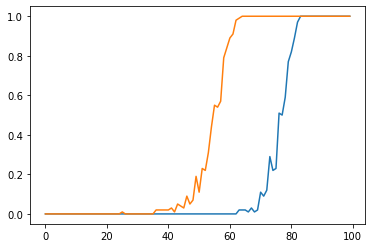

In [17]:
plt.plot(range(100),res[0])
plt.plot(range(100),res[1])
plt.show()